In [41]:
import urllib.request
import datetime
import json
import xmltodict
import pandas as pd
import matplotlib.pyplot as plt

In [42]:
# 요청 보내고 응답 받는 함수
def getRequestUrl(url):
    try:
        response = urllib.request.urlopen(url)
        if response.getcode() == 200:
            print("[%s] Url Request Success" %datetime.datetime.now())
            return response.read().decode('utf-8')
    except Exception as e:
        print(e)
        print("[%s] Error for URL : %s" %(datetime.datetime.now(), url))
        return None


In [43]:
# url 확정하고 응답결과를 dictionary로 파싱해서 반환하는 함수
def getSatisfaction(key, pageNo, numOfRows):
    base = "https://apis.data.go.kr/1741000/SatisfactionEGovernmentService/getSatisfactionEGovernmentService"

    parameters = "?ServiceKey=%s&pageNo=%s&numOfRows=%s" %(key, pageNo, numOfRows)

    url = base + parameters
    responseDecode = getRequestUrl(url)

    if(responseDecode == None):
        return None
    else:
        return xmltodict.parse(responseDecode) # XML -> dictionary

In [44]:
# 하나씩 리스트로 정리하는 함수
def getDataToList(post, jsonResult, cnt):
    year = post.get('wrttimeid')
    teen = post.get('age_sixteen_above_nineteen_below')
    twenty = post.get('age_twenty')
    thirty = post.get('age_thirty')
    forty = post.get('age_forty')
    fifty = post.get('age_fifty')
    sixty_and_over = post.get('age_sixty_above_sentyfour_below')

    jsonResult.append({'cnt':cnt, 'year':year, 'teen':teen, 'twenty':twenty, 'thirty':thirty, 'forty':forty, 'fifty':fifty, 'sixty_and_over':sixty_and_over})
    return

In [45]:
# 나잇대별 만족도 평균을 내는 함수
def average(json_filename):
    with open (json_filename, 'r', encoding='utf-8') as f:
        data = json.load(f)

    df = pd.DataFrame(data)
    columns = ['teen', 'twenty', 'thirty', 'forty', 'fifty', 'sixty_and_over']
    for col in columns :
        df[col] = pd.to_numeric(df[col]) # 문자열이었던 숫자 데이터들 다 float로 변환
    
    age_average = df[columns].mean()
    print(age_average)
    return age_average

In [46]:
# 시각화 하는 함수
def visualize(age_average):
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['axes.unicode_minus'] = False
    plt.figure(figsize=(8, 5))
    age_average.index = ['10대', '20대', '30대', '40대','50대','60대 이상']
    colors = ['skyblue','skyblue','skyblue','skyblue','skyblue','red']
    plt.bar(age_average.index, age_average.values, color=colors)
    plt.title("2012 ~ 2024 연령별 전자정부서비스 만족도 평균")
    plt.ylabel("연령별 만족도")
    plt.xlabel("연령대")
    plt.ylim(70,90)
    plt.grid(axis='y')
    plt.show()

In [47]:
def main():
    key = '807bc138c4490c6a503eb4fd44441798bd8457348534a8e52877b215ec088f5f'
    jsonResult = []
    cnt = 0
    pageNo = 1
    numOfRows = 20

    jsonResponse = getSatisfaction(key, pageNo, numOfRows)

    if jsonResponse is None:
        print("데이터를 가져오지 못했습니다.")
        return

    try:
        result = jsonResponse['SatisfactionEGovernmentService']
        data = result['row']
        total_count = int(result['head']['totalCount'])
    except Exception as e:
        return

    for post in data:
        cnt += 1
        getDataToList(post, jsonResult, cnt)
    
    print("전체 검색 결과: %d건" % cnt)

    json_filename = "satisfaction.json"
    with open(json_filename, 'w', encoding='utf-8') as f:
        json.dump(jsonResult, f, indent=4, ensure_ascii=False)

    print("파일 저장 완료: %s" %json_filename)

    age_average = average(json_filename)
    visualize(age_average)
    

[2025-11-23 18:27:14.740235] Url Request Success
전체 검색 결과: 13건
파일 저장 완료: satisfaction.json
teen              80.600000
twenty            81.392308
thirty            81.576923
forty             81.253846
fifty             80.846154
sixty_and_over    78.400000
dtype: float64


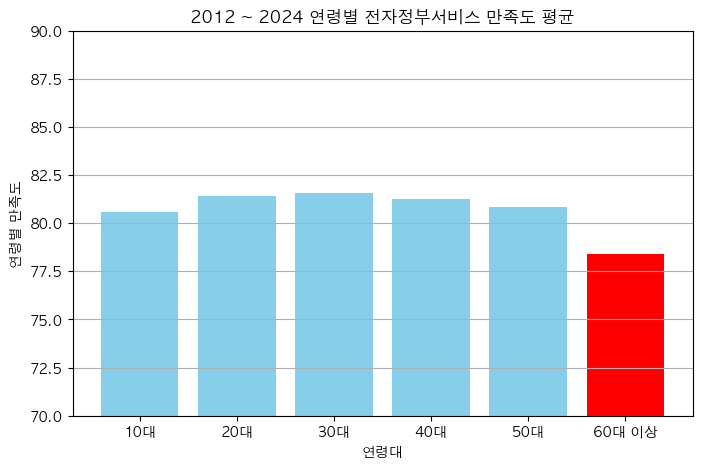

In [48]:
if __name__ == '__main__':
    main()